# Black Friday Sales Analysis using Python

**Submitted by:** Shashank kumar Thakur, Aashman Rai, Siddhant Srivastava  
**Course:** BCA (AI & ML)  
**University:** Galgotias University  
**Tool Used:** Jupyter Notebook  


## Introduction

Black Friday is one of the biggest shopping events, generating massive sales data.
Analyzing this data helps businesses understand customer behavior, spending patterns,
and product demand.

This project uses Python to analyze Black Friday sales data, perform data cleaning,
exploratory data analysis, and apply machine learning models to predict purchase amounts.


## Problem Statement

The objective of this project is to analyze Black Friday sales data to identify
key factors influencing customer purchase behavior and to build predictive models
that estimate purchase amounts.


## Objectives

- To clean and preprocess Black Friday sales data
- To perform exploratory data analysis (EDA)
- To identify important factors affecting purchase amount
- To compare multiple machine learning models
- To select the best performing model


## Importing the necessary libraries

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

## Dataset Description

The dataset contains customer demographics, product categories,
and purchase amounts collected during Black Friday sales.


In [70]:
file_path = "Black_Friday_sales.csv"
df = pd.read_csv(file_path)

In [71]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


## Data Cleaning

Data cleaning was performed to handle missing values, correct data types,
and ensure consistency for machine learning models.


# Check number of rows and columns

In [72]:
df.shape

(537577, 12)

# Get dataset information

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


# Check missing values

In [74]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

# Fill missing values with 0

In [75]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(0)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0)

# Verify missing values again
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

# Check duplicate rows

In [76]:
df.duplicated().sum()

np.int64(0)

# Check Data Types of ALl columns

In [77]:
df.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

# Changing the data type of Stay_In_Current_City_Years from str to int

In [78]:
df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].replace("4+", 4)
df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].astype("int")

In [79]:
df["Stay_In_Current_City_Years"]

0         2
1         2
2         2
3         2
4         4
         ..
537572    1
537573    1
537574    1
537575    1
537576    1
Name: Stay_In_Current_City_Years, Length: 537577, dtype: int64

# Save cleaned dataset

In [80]:
df.to_csv("Black_Friday_Cleaned.csv", index=False)

# Load cleaned dataset

In [81]:
df = pd.read_csv("Black_Friday_Cleaned.csv")

df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0.0,0.0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0.0,0.0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,0.0,1057
4,1000002,P00285442,M,55+,16,C,4,0,8,0.0,0.0,7969


# Checking Outliner of Purchase Column

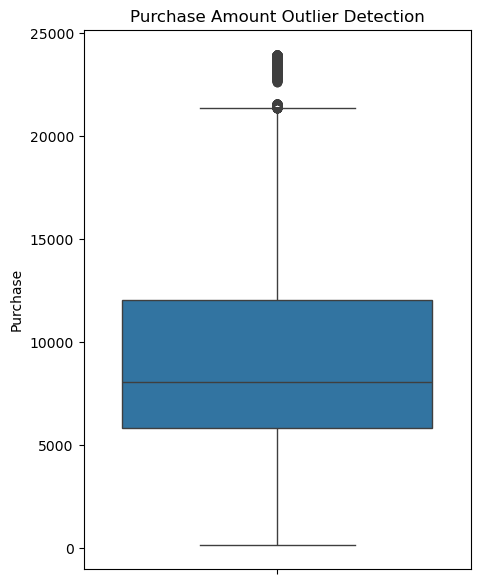

In [82]:
plt.figure(figsize=(5, 7))
sns.boxplot(y=df['Purchase'])
plt.title("Purchase Amount Outlier Detection")
plt.show()

## Exploratory Data Analysis (EDA)

EDA helps understand customer behavior and spending patterns
through statistical summaries and visualizations.


In [83]:
df.describe()

,User_ID,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.375770e+05,537577.00000,537577.000000,537577.000000,537577.000000,537577.000000,537577.000000,537577.000000
mean,1.002992e+06,8.08271,1.859458,0.408797,5.295546,6.784907,3.871773,9333.859853
std,1.714393e+03,6.52412,1.289828,0.491612,3.750701,6.211618,6.265963,4981.022133
min,1.000001e+06,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,185.000000
25%,1.001495e+06,2.00000,1.000000,0.000000,1.000000,0.000000,0.000000,5866.000000
50%,1.003031e+06,7.00000,2.000000,0.000000,5.000000,5.000000,0.000000,8062.000000
75%,1.004417e+06,14.00000,3.000000,1.000000,8.000000,14.000000,8.000000,12073.000000
max,1.006040e+06,20.00000,4.000000,1.000000,18.000000,18.000000,18.000000,23961.000000


## Gender-wise Purchase Analysis

In [84]:
df.groupby('Gender')['Purchase'].mean()

Gender
F    8809.761349
M    9504.771713
Name: Purchase, dtype: float64

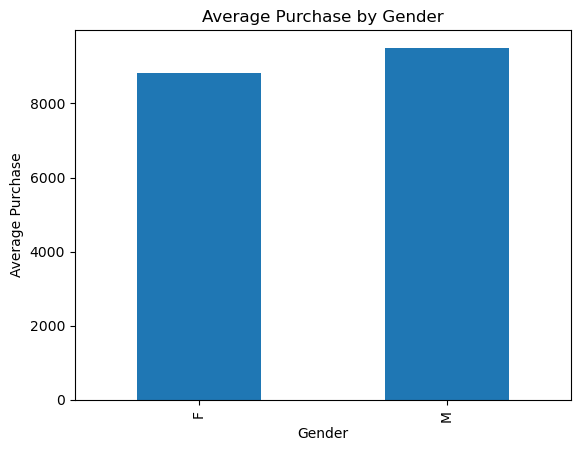

In [85]:
df.groupby('Gender')['Purchase'].mean().plot(kind='bar', title='Average Purchase by Gender')
plt.ylabel("Average Purchase")
plt.show()

Observation:
Male customers show higher average purchase amounts compared to female customers.


# Age-wise Purchase Analysis

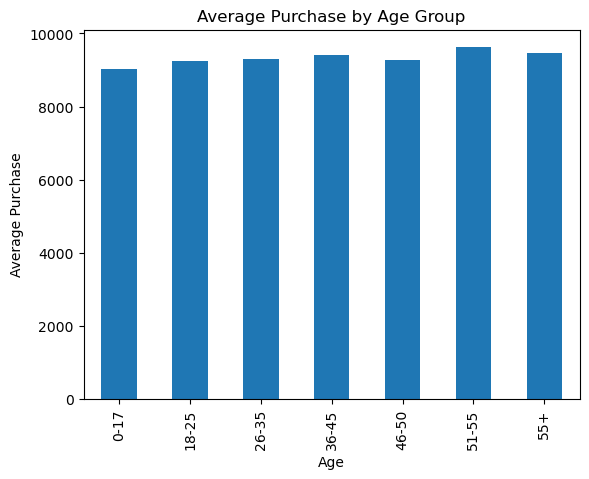

In [86]:
df.groupby('Age')['Purchase'].mean().plot(kind='bar', title='Average Purchase by Age Group')
plt.ylabel("Average Purchase")
plt.show()


- The 51–55 age group has the highest average purchase.
- The 0–17 age group has the lowest average purchase.

# City Category Analysis

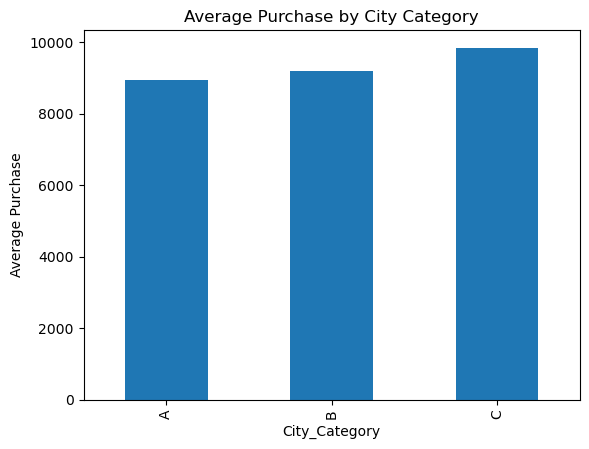

In [87]:
df.groupby('City_Category')['Purchase'].mean().plot(kind='bar', title='Average Purchase by City Category')
plt.ylabel("Average Purchase")
plt.show()


- City Category B and C show higher spending